Dataset overview

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,StandardScaler
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier,KNeighborsRegressor
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,roc_auc_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [ ]:
df=pd.read_csv('/content/drive/MyDrive/ML_AL/House_Pricing.csv')
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)
df.head()




,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,Fair,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,Fair,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,Fair,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,Excellent,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,Fair,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


In [ ]:
df.tail()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
21608,263000018,14 May 2017,360000.0,3,2.50,1530.0,1131.0,3.0,No,NaN,Fair,8,1530.0,0,9,0,98103.0,47.6993,-122.346,1530.0,1509
21609,6600060120,15 February 2016,400000.0,4,2.50,2310.0,5813.0,2.0,No,NaN,Fair,8,2310.0,0,4,0,98146.0,47.5107,-122.362,1830.0,7200
21610,1523300141,14 June 2017,402101.0,2,0.75,1020.0,1350.0,2.0,No,NaN,Fair,7,1020.0,0,9,0,98144.0,47.5944,-122.299,1020.0,2007
21611,291310100,15 January 2016,400000.0,3,2.50,1600.0,2388.0,2.0,No,NaN,Fair,8,1600.0,0,14,0,98027.0,47.5345,-122.069,1410.0,1287
21612,1523300157,14 October 2017,325000.0,2,0.75,1020.0,1076.0,2.0,No,NaN,Fair,7,1020.0,0,10,0,98144.0,47.5941,-122.299,1020.0,1357


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [ ]:
df.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [ ]:
df.dtypes

,0
ID,int64
Date House was Sold,object
Sale Price,float64
No of Bedrooms,int64
No of Bathrooms,float64
Flat Area (in Sqft),float64
Lot Area (in Sqft),float64
No of Floors,float64
Waterfront View,object
No of Times Visited,object


Duplicate removal

In [ ]:
#duplicated rows
df.duplicated().sum()

np.int64(0)

In [ ]:
#duplicated columns
df.T.duplicated().sum()

np.int64(0)

Handling missing values

In [ ]:
#finding missing values
df.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [ ]:
(df.isna().sum()/len(df)*100)

,0
ID,0.000000
Date House was Sold,0.000000
Sale Price,0.018507
No of Bedrooms,0.000000
No of Bathrooms,0.018507
Flat Area (in Sqft),0.041642
Lot Area (in Sqft),0.041642
No of Floors,0.000000
Waterfront View,0.000000
No of Times Visited,90.172581


In [ ]:
#dropping the column "no of time visited " becouse it has 90% missing values
df=(df.drop(columns=['No of Times Visited','ID']))

In [ ]:
df.isna().sum()

,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
Condition of the House,0
Overall Grade,0


In [ ]:
#numerical values
numerical_columns=df.select_dtypes(include='number').columns

In [ ]:
#categorical values
categorical_columns=df.select_dtypes(include="object").columns

Encoding

In [ ]:
#spitting into month and year
df['Date House was Sold'] = pd.to_datetime(df['Date House was Sold'])

df['Year'] = df['Date House was Sold'].dt.year
df['Month'] = df['Date House was Sold'].dt.month

In [ ]:
#label encoding
label_cols=['Condition of the House']
le=LabelEncoder()
for cols in label_cols:
  df[cols]=le.fit_transform(df[cols])

In [ ]:
#onehotencoding for nominal categories
df = pd.get_dummies(df,columns=["Waterfront View"],drop_first=True,dtype=int)
df.head()

,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Year,Month,Waterfront View_Yes
0,2017-10-14,221900.0,3,1.00,1180.0,5650.0,1.0,2,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650,2017,10,0
1,2017-12-14,538000.0,3,2.25,2570.0,7242.0,2.0,2,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639,2017,12,0
2,2016-02-15,180000.0,2,1.00,770.0,10000.0,1.0,2,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062,2016,2,0
3,2017-12-14,604000.0,4,3.00,1960.0,5000.0,1.0,1,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000,2017,12,0
4,2016-02-15,510000.0,3,2.00,1680.0,8080.0,1.0,2,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503,2016,2,0


Outlier removal

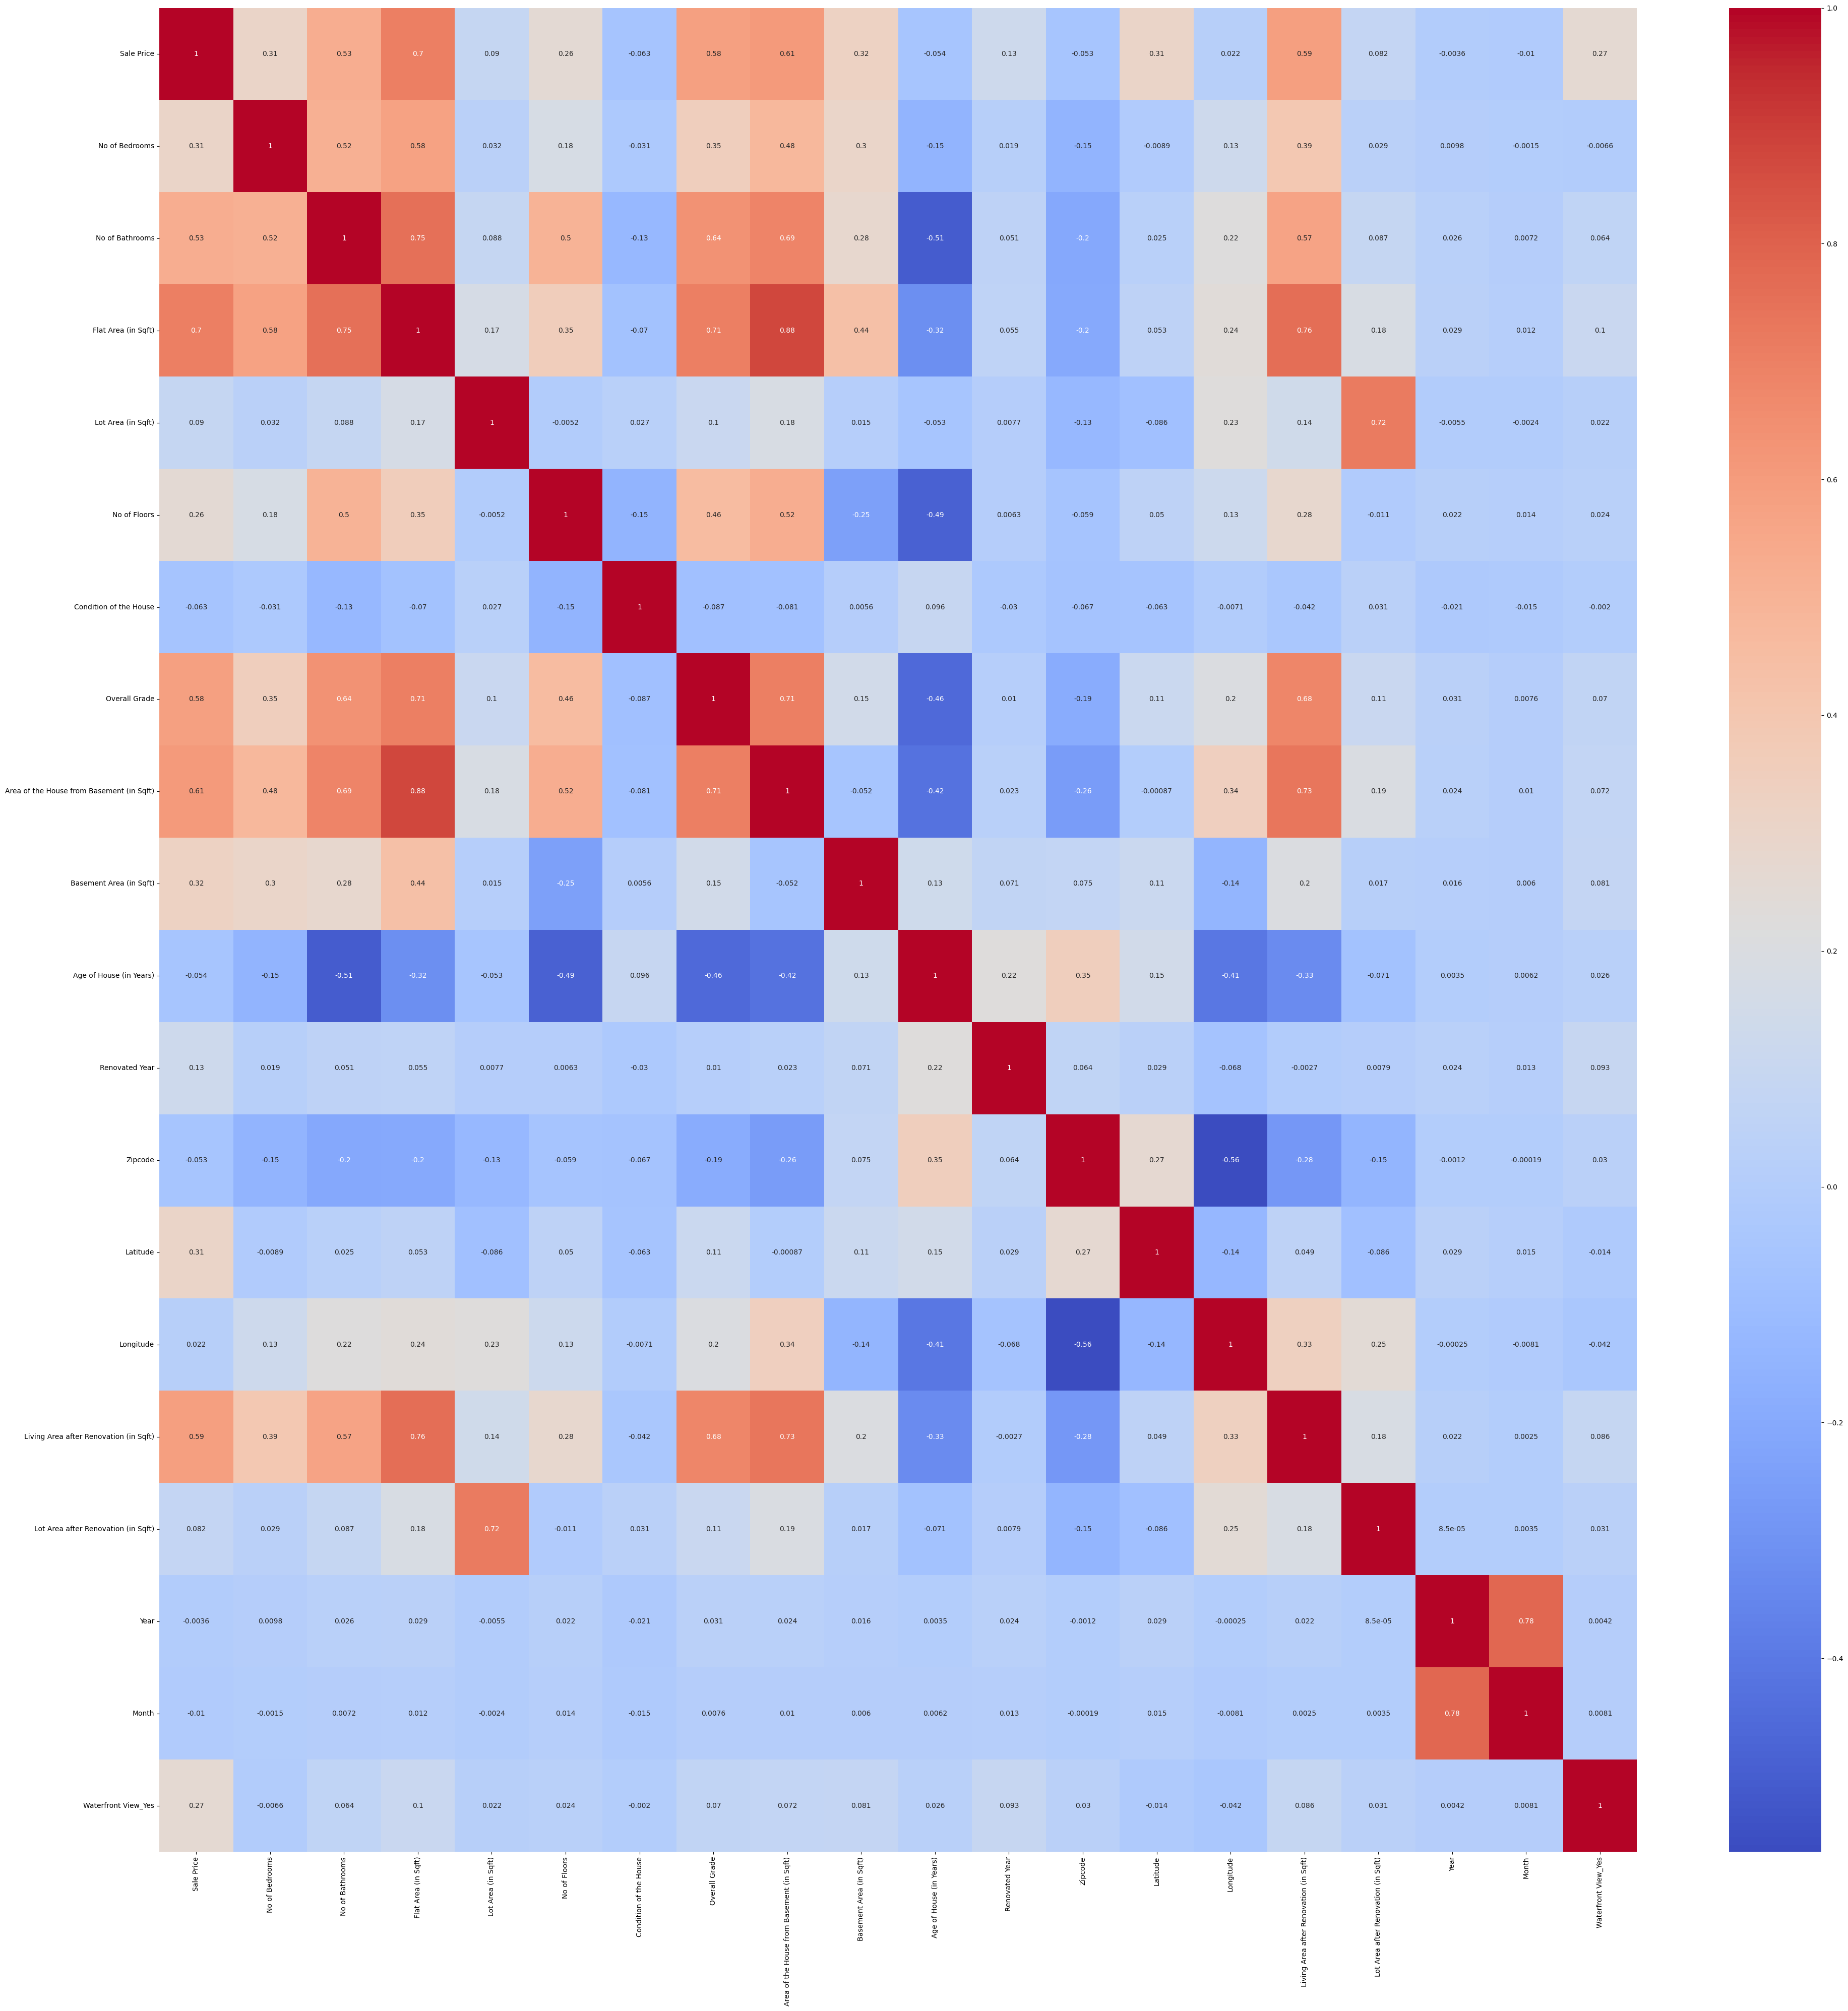

In [ ]:
#correlation
corr_result = df.select_dtypes(include='number').corr()

plt.figure(figsize=(40,40))
sns.heatmap(
    corr_result,
    cmap="coolwarm",
    annot=True
)

plt.tight_layout()
plt.show()

In [ ]:
df.columns.tolist()

['Date House was Sold',
 'Sale Price',
 'No of Bedrooms',
 'No of Bathrooms',
 'Flat Area (in Sqft)',
 'Lot Area (in Sqft)',
 'No of Floors',
 'Condition of the House',
 'Overall Grade',
 'Area of the House from Basement (in Sqft)',
 'Basement Area (in Sqft)',
 'Age of House (in Years)',
 'Renovated Year',
 'Zipcode',
 'Latitude',
 'Longitude',
 'Living Area after Renovation (in Sqft)',
 'Lot Area after Renovation (in Sqft)',
 'Year',
 'Month',
 'Waterfront View_Yes']

In [ ]:
columns_to_select = [
    'Basement Area (in Sqft)',
    'Living Area after Renovation (in Sqft)',
    'Area of the House from Basement (in Sqft)',
    'Sale Price'
]

columns_to_reject = [col for col in df.columns if col not in columns_to_select]

df = df.drop(columns=columns_to_reject)

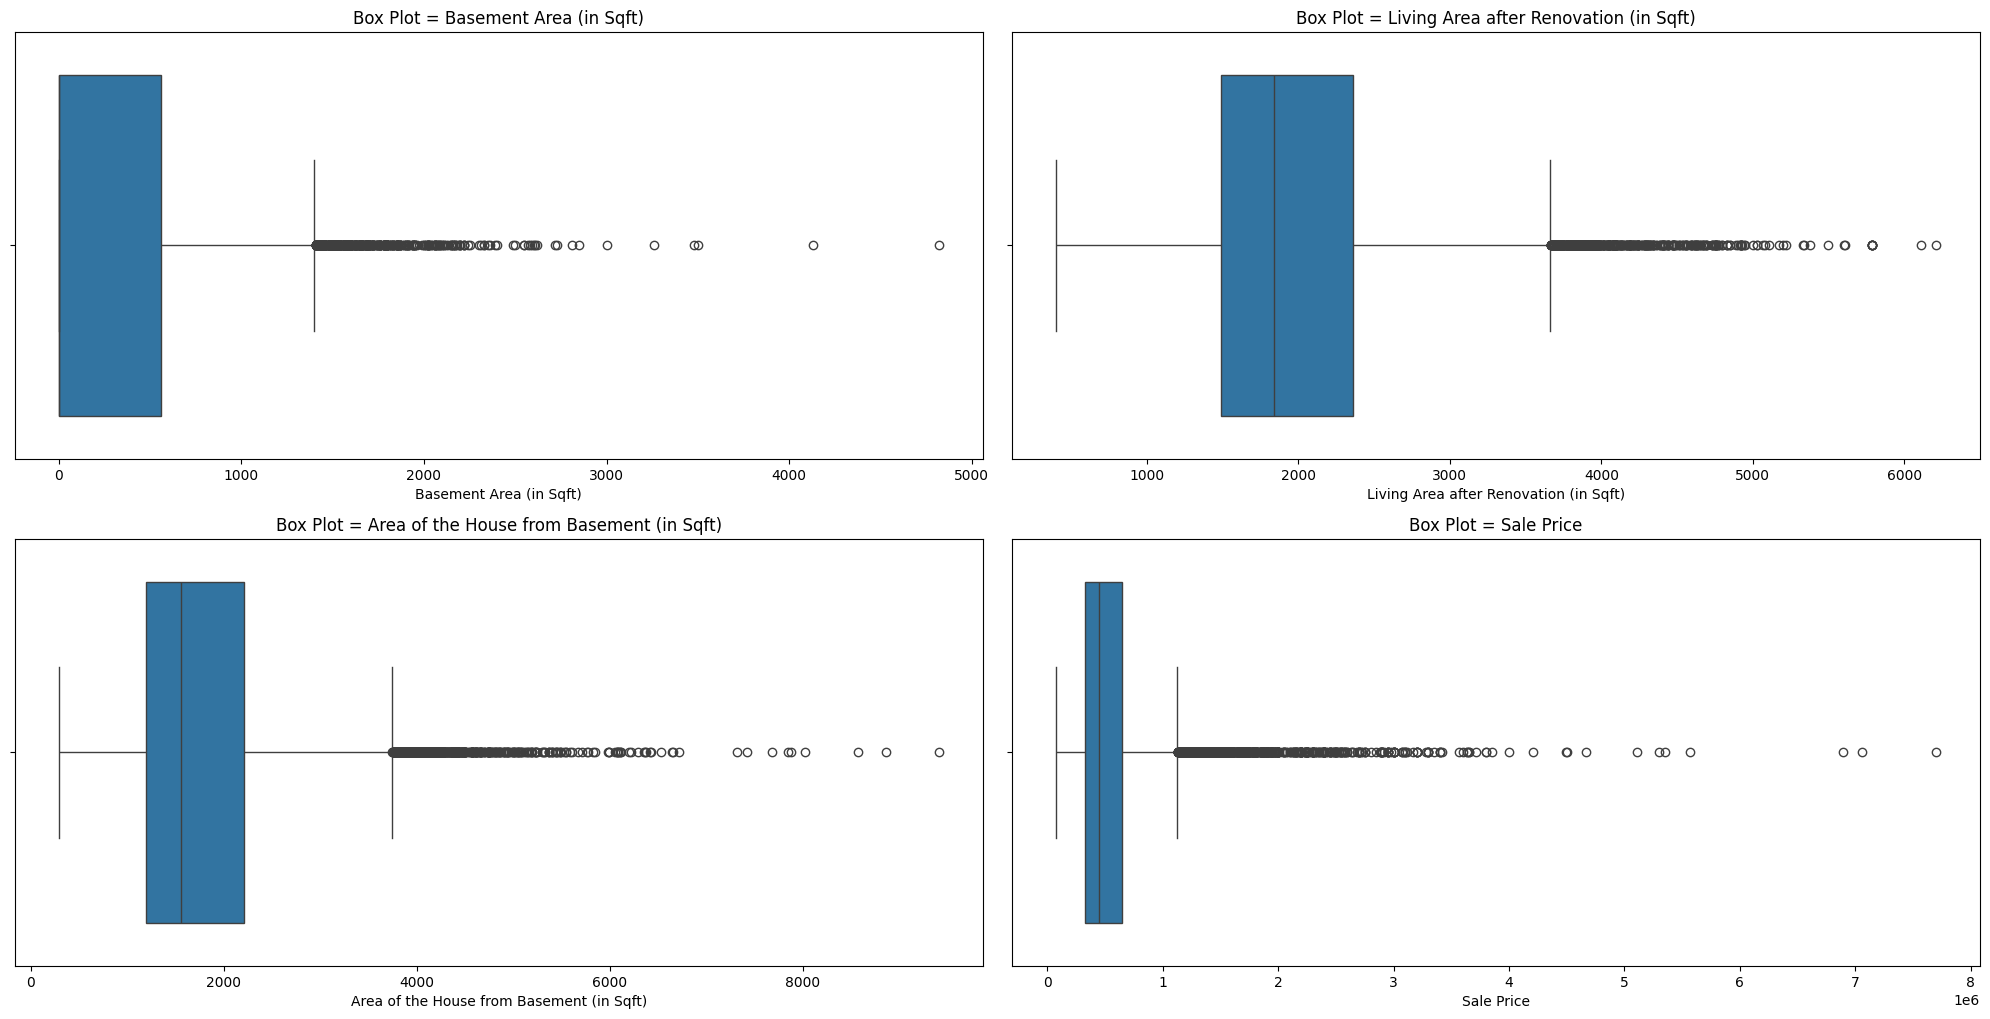

In [ ]:
columns = columns_to_select
plt.figure(figsize=(20,20))

for i ,col in enumerate(columns):
  plt.subplot(len(columns), 2,i+1)
  sns.boxplot(x=df[col])
  plt.title(f"Box Plot = {col}")

plt.tight_layout()
plt.show()

In [ ]:
# Check missing values after selecting the required columns

print(df.isna().sum())

Sale Price                                   0
Area of the House from Basement (in Sqft)    3
Basement Area (in Sqft)                      0
Living Area after Renovation (in Sqft)       1
dtype: int64


In [ ]:
print(df.isna().sum())

Sale Price                                   0
Area of the House from Basement (in Sqft)    3
Basement Area (in Sqft)                      0
Living Area after Renovation (in Sqft)       1
dtype: int64


In [ ]:
columns_to_select.remove('Sale Price')

In [ ]:
columns = columns_to_select

for col in columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    IQR = q3 - q1

    upper_bound = q3 + 1.5 * IQR
    lower_bound = q1 - 1.5 * IQR

    outlier = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print("Column:", col)
    print("Number of outliers:", len(outlier))

Column: Basement Area (in Sqft)
Number of outliers: 496
Column: Living Area after Renovation (in Sqft)
Number of outliers: 544
Column: Area of the House from Basement (in Sqft)
Number of outliers: 610
Column: Sale Price
Number of outliers: 1159


In [ ]:
X = df.drop('Sale Price', axis=1)
y = df['Sale Price']

In [ ]:
#checking
print("X shape:", X.shape)
print("y shape:", y.shape)

print("Missing values in X:")
print(X.isna().sum())

print("Missing values in y:")
print(y.isna().sum())

X shape: (21609, 3)
y shape: (21609,)
Missing values in X:
Area of the House from Basement (in Sqft)    3
Basement Area (in Sqft)                      0
Living Area after Renovation (in Sqft)       1
dtype: int64
Missing values in y:
0


In [ ]:
#train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#checking
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("Missing y_train:", y_train.isna().sum())
print("Missing y_test:", y_test.isna().sum())

X_train: (17287, 3)
X_test: (4322, 3)
Missing y_train: 0
Missing y_test: 0


In [ ]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [ ]:
#checking
print("Missing values after imputation:")
print(np.isnan(X_train_imputed).sum())
print(np.isnan(X_test_imputed).sum())

Missing values after imputation:
0
0


In [ ]:
#scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)

X_test_scaled = scaler.transform(X_test_imputed)

In [ ]:
#checking
print("NaN in X_train_scaled:", np.isnan(X_train_scaled).sum())
print("NaN in X_test_scaled:", np.isnan(X_test_scaled).sum())

NaN in X_train_scaled: 0
NaN in X_test_scaled: 0


**MODEL BUILDING AND EVALUATION**

LINEAR REGRESSION

In [ ]:
#model-1 linear regression
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
# Make predictions
y_pred_lr = lr_model.predict(X_test_scaled)

In [ ]:
#evaluation
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("-------------------------")
print("MAE  :", mae_lr)
print("MSE  :", mse_lr)
print("RMSE :", rmse_lr)
print("R²   :", r2_lr)

Linear Regression
-------------------------
MAE  : 173295.83073251828
MSE  : 72613769771.48727
RMSE : 269469.4227022563
R²   : 0.5020768233838764


In [83]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


KNN

In [ ]:
#model-2-KNN
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
#prediction
y_pred_knn = knn_model.predict(X_test_scaled)

In [ ]:
#evaluation
mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("KNN Regression")
print("-------------------------")
print("MAE  :", mae_knn)
print("MSE  :", mse_knn)
print("RMSE :", rmse_knn)
print("R²   :", r2_knn)

KNN Regression
-------------------------
MAE  : 171079.59148542344
MSE  : 68786980648.17946
RMSE : 262272.72189112514
R²   : 0.5283176727780592


RANDOM FOREST


In [ ]:
#model-3-random forest
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train_imputed, y_train)
#prediction
y_pred_rf = rf_model.predict(X_test_imputed)

In [ ]:
#evaluation
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regression")
print("-------------------------")
print("MAE  :", mae_rf)
print("MSE  :", mse_rf)
print("RMSE :", rmse_rf)
print("R²   :", r2_rf)

Random Forest Regression
-------------------------
MAE  : 168393.3903689495
MSE  : 66608558249.862045
RMSE : 258086.33875093437
R²   : 0.5432554318834656


SVM

In [ ]:
#model-4-SVM
from sklearn.svm import SVR
svm_model = SVR(kernel='rbf')
svm_model.fit(X_train_scaled, y_train)
#prediction
y_pred_svm = svm_model.predict(X_test_scaled)

In [ ]:
#evaluation
mae_svm = mean_absolute_error(y_test, y_pred_svm)
mse_svm = mean_squared_error(y_test, y_pred_svm)
rmse_svm = np.sqrt(mse_svm)
r2_svm = r2_score(y_test, y_pred_svm)

print("SVM Regression")
print("-------------------------")
print("MAE  :", mae_svm)
print("MSE  :", mse_svm)
print("RMSE :", rmse_svm)
print("R²   :", r2_svm)

SVM Regression
-------------------------
MAE  : 226090.08822352948
MSE  : 154647766844.95883
RMSE : 393252.8027172328
R²   : -0.06044222144582334


MODEL COMPARISON AND PRINTING BEST MODEL

In [ ]:
# Model Comparison

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "KNN Regression",
        "Random Forest Regression",
        "SVM Regression"
    ],
    "MAE": [
        mae_lr,
        mae_knn,
        mae_rf,
        mae_svm
    ],
    "MSE": [
        mse_lr,
        mse_knn,
        mse_rf,
        mse_svm
    ],
    "RMSE": [
        rmse_lr,
        rmse_knn,
        rmse_rf,
        rmse_svm
    ],
    "R²": [
        r2_lr,
        r2_knn,
        r2_rf,
        r2_svm
    ]
})

results

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,173295.830733,7.261377e+10,269469.422702,0.502077
1,KNN Regression,171079.591485,6.878698e+10,262272.721891,0.528318
2,Random Forest Regression,168393.390369,6.660856e+10,258086.338751,0.543255
3,SVM Regression,226090.088224,1.546478e+11,393252.802717,-0.060442


In [88]:
# Best model based on R2

best_model = results.loc[results["R²"].idxmax()]

print("Best Model:")
print(best_model)

Best Model:
Model    Random Forest Regression
MAE                 168393.390369
MSE            66608558249.862045
RMSE                258086.338751
R²                       0.543255
Name: 2, dtype: object


**Conclusion**

In this case study, the House Pricing dataset was preprocessed by handling missing values, removing unnecessary columns, encoding categorical variables, selecting relevant features, detecting outliers, and applying feature scaling.

Four supervised machine learning regression algorithms were implemented: Linear Regression, KNN Regression, Random Forest Regression, and SVM Regression. The models were evaluated using MAE, MSE, RMSE, and R² score.

Among the four models, Random Forest Regression performed the best, achieving the lowest RMSE and MAE and the highest R² score. Therefore, Random Forest Regression was selected as the best-performing model for predicting house sale prices in this case study.

Overall, the results show that ensemble-based Random Forest Regression provided better predictive performance than the other models used in this study.